## Задача 1.  Матричные вычисления, оценка скорости и погрешностей (5 баллов).

1. Напишите функцию, которая вычисляет корень степени $p$ из матрицы размера $2 \times 2$, используя явную формулу для произвольной аналитической функции от матрицы

$$
f(A)=\frac{f\left(\lambda_{+}\right)+f\left(\lambda_{-}\right)}{2} I+\frac{A-\left(\frac{\operatorname{tr}(A)}{2}\right) I}{\sqrt{\left(\frac{\operatorname{tr}(A)}{2}\right)^2-|A|}} \frac{f\left(\lambda_{+}\right)-f\left(\lambda_{-}\right)}{2},
$$

Здесь:

$$
\lambda_{ \pm}=\frac{\operatorname{tr}(A)}{2} \pm \sqrt{\left(\frac{\operatorname{tr}(A)}{2}\right)^2-|A|}
$$

А в случае кратных собственных чисел предельный переход в формуле дает

$$
f(A)=f\left(\frac{\operatorname{tr}(A)}{2}\right) I+\operatorname{adj}\left(\frac{\operatorname{tr}(A)}{2} I-A\right) f^{\prime}\left(\frac{\operatorname{tr}(A)}{2}\right)
$$


Функция должна уметь обрабатывать все такие матрицы. Функция должна отдельно обрабатывать случай $\left(\frac{\operatorname{tr}(A)}{2}\right)^2-|A| = 0$.

Нужно отметить, что если мы считаем логарифм от матрицы $A$ и считаем результат матрицей вещественными числами, то это значит, что матрица $A$ сама является экспонентой от матрицы с вещественными числами. Это автоматически означает, что ее след больше нуля и вещественная часть всех её собственных чисел больше нуля.

Отдельный вопрос, что делать в случае комплексных собственных чисел. Для этого перепишем дробь:



$$
\frac{f\left(\lambda_{+}\right)-f\left(\lambda_{-}\right)}{i \cdot \sqrt{\left(\frac{-\operatorname{tr}(A)}{2}\right)^2+|A|}} = \frac{2 \cdot arctg(p/u)}{p}; \ p = \sqrt{\left(\frac{-\operatorname{tr}(A)}{2}\right)^2+|A|}
$$



Пункты 2-4 проделайте для матриц с вещественными различными собственными числами. Для вычисления логарифма используйте numpy.log() https://numpy.org/doc/stable/reference/generated/numpy.log.html


2. Напишите функцию, которая генерирует большое количество случайных матриц размера $2 \times 2$, состоящих из вещественных чисел из диапазона от 0 до 1 и для каждой вычисляет логарифм. Постройте график зависимости времени работы программы в зависимости от количества вычисляемых логарифмов.  

3. Напишите функцию, которая генерирует большое количество (не менее 1000) матриц размера $2 \times 2$, которые являются экспонентами от случайных матриц, использовать встроенную функцию numpy.exp() https://numpy.org/doc/stable/reference/generated/numpy.exp.html. Полученные случайные матрицы тоже нужно сохранить. Они нужны для вычисления ошибки написанного вами алгоритма. Постройте график относительной ошибки вычислений логарифмов от этих матриц (по спектральной норме) в зависимости от числа обусловленности сгенерированной матрицы.

4. После выполнения пункта 3 выберите какую-то одну матрицу из этого множества с большим числом обусловленности, сгенерируйте 1000 случайных матриц для возмущений, элементы которых вещественные числа, распределенные равномерно в диапазоне от -0.01 до 0.01. Постройте график спектральной нормы разницы точного значения логарифма и вычисляемого по формулам из суммы матрицы и её возмущения, в зависимости от нормы возмущения. Затем возьмите матрицу с маленьким числом обусловленности и проделайте то же самое.

5. Возьмите какую-то одну матрицу. Возведите её в степень $N$ для последовательных значений $N$ в диапазоне от 1 до 100 и сохраните степени этой матрицы. Для каждой степени матрицы возьмите матричный логарифм. Постройте график зависимости относительной ошибки вычислений логарифма по спектральной норме от числа $N$.

### 1

In [73]:
import numpy as np
from numpy.linalg import norm, eig, det
import time
import matplotlib.pyplot as plt


def matrix_function_2x2(A: np.ndarray, f, fprime=None):

    if fprime is None:
        eps = 1e-8
        fprime = lambda x: (f(x + eps) - f(x - eps)) / (2 * eps)
    
    A = np.asarray(A)
    assert A.shape == (2, 2)
    tr = np.trace(A)
    half_tr = 0.5 * tr
    delta = half_tr * half_tr - det(A)

    I = np.eye(2)

    # Same eigenvalues
    if np.isclose(delta, 0.0, atol=1e-14, rtol=0.0):
        
        lam = half_tr
        a, b = A[0, 0], A[0, 1]
        c, d = A[1, 0], A[1, 1]
        adj_term = np.array([[d - lam, -b], [-c, a - lam]], dtype=complex)
        FA = f(lam) * I + adj_term * fprime(lam)
        FA = np.real_if_close(FA, tol=1e8)
        return FA.astype(float) if np.isrealobj(FA) else FA

    # Distinct eigenvalues
    sqrt_delta = np.sqrt(delta + 0j)
    lam_plus = half_tr + sqrt_delta
    lam_minus = half_tr - sqrt_delta

    centered = A - half_tr * I
    num = f(lam_plus) - f(lam_minus)
    denom = 2 * sqrt_delta
    second_coef = num / denom
    first_coef = 0.5 * (f(lam_plus) + f(lam_minus))
    FA = first_coef * I + second_coef * centered
    FA = np.real_if_close(FA, tol=1e8)
    return FA.astype(float) if np.isrealobj(FA) else FA


def matrix_log_2x2(A: np.ndarray) -> np.ndarray:

    return matrix_function_2x2(A, np.log, fprime=lambda x: 1.0 / x)


def matrix_power_2x2(A: np.ndarray, p: float) -> np.ndarray:

    if np.isclose(p, int(p)):
        # For integer powers, fall back to numpy for stability/speed
        return np.linalg.matrix_power(A, int(round(p)))
    f = lambda x: x ** p
    fprime = lambda x: p * (x ** (p - 1))
    return matrix_function_2x2(A, f, fprime=fprime)


def relative_error(A: np.ndarray, B: np.ndarray, ord=2) -> float:
    return norm(A - B, ord=ord) / max(norm(B, ord=ord), 1e-16)


def generate_random_real_distinct_2x2(n: int, low=0.0, high=1.0, seed: int | None = None):
    rng = np.random.default_rng(seed)
    mats = []
    while len(mats) < n:
        M = rng.uniform(low, high, size=(2, 2))
        vals = eig(M)[0]
        # только с вещественными различными собственными значениями
        if np.allclose(vals.imag, 0, atol=1e-10) and np.abs(vals[0].real - vals[1].real) > 1e-8:
            mats.append(M)
    return np.array(mats)


def generate_exponential_family(n: int, seed: int | None = None):

    rng = np.random.default_rng(seed)
    Ms = []
    As = []
    while len(Ms) < n:
        M = rng.normal(0, 1, size=(2, 2))
        M = 0.5 * (M + M.T)
        A = matrix_function_2x2(M, np.exp, fprime=np.exp)
        vals = eig(A)[0]
        if np.allclose(vals.imag, 0, atol=1e-10) and np.abs(vals[0].real - vals[1].real) > 1e-8 and np.all(vals.real > 0):
            Ms.append(M)
            As.append(A.astype(float))
    return np.array(Ms), np.array(As)


### 2

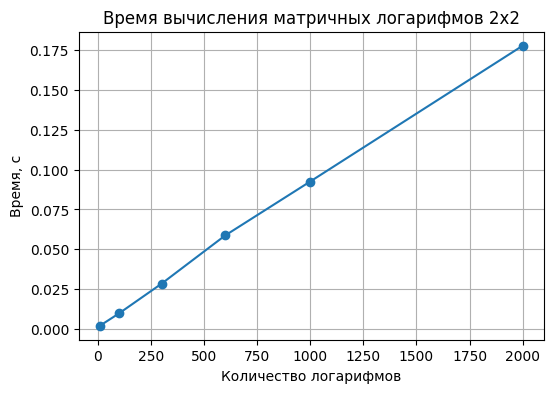

In [74]:
counts = [10, 100, 300, 600, 1000, 2000]

times = []
rng = np.random.default_rng(42)
for k in counts:
    mats = generate_random_real_distinct_2x2(k, low=0.0, high=1.0, seed=rng.integers(1e9))
    t0 = time.perf_counter()
    _ = [matrix_log_2x2(M) for M in mats]
    t1 = time.perf_counter()
    times.append(t1 - t0)

plt.figure(figsize=(6, 4))
plt.plot(counts, times, marker='o')
plt.xlabel('Количество логарифмов')
plt.ylabel('Время, с')
plt.title('Время вычисления матричных логарифмов 2x2')
plt.grid(True)
plt.show()


### 3

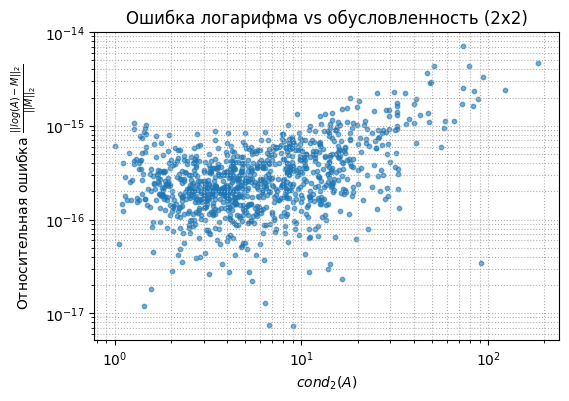

(np.float64(185.4428540592861), np.float64(1.0102292991105764))

In [75]:
Ms, As = generate_exponential_family(1000, seed=7)

conds = np.array([np.linalg.cond(A, 2) for A in As])
errs = np.array([relative_error(matrix_log_2x2(A), M, ord=2) for A, M in zip(As, Ms)])

plt.figure(figsize=(6, 4))
plt.scatter(conds, errs, s=10, alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$cond_2(A)$')
plt.ylabel(r'Относительная ошибка $\frac{||log(A) - M||_2}{||M||_2}$')
plt.title('Ошибка логарифма vs обусловленность (2x2)')
plt.grid(True, which='both', ls=':')
plt.show()

# Сохраним индексы матриц с наибольшей и наименьшей обусловленностью для п.4
idx_hi = int(np.argmax(conds))
idx_lo = int(np.argmin(conds))
A_hi, M_hi = As[idx_hi], Ms[idx_hi]
A_lo, M_lo = As[idx_lo], Ms[idx_lo]
cond_hi, cond_lo = conds[idx_hi], conds[idx_lo]
cond_hi, cond_lo


### 4

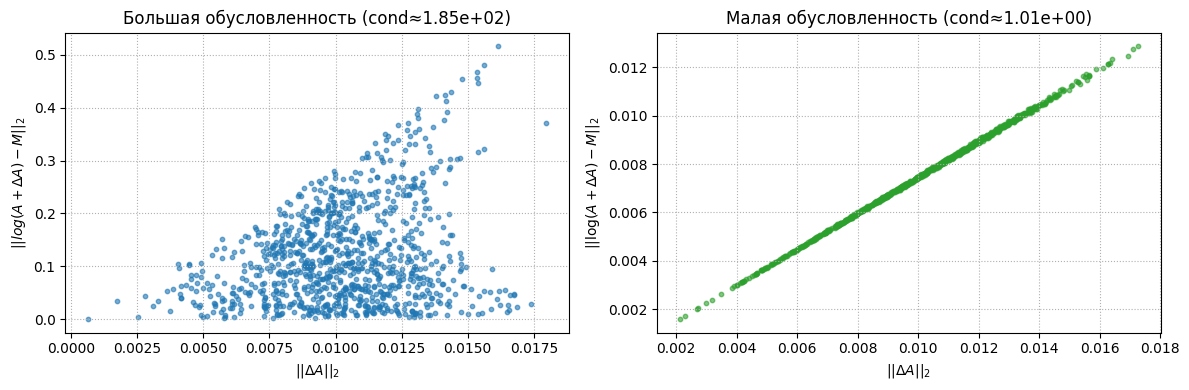

In [76]:
rng = np.random.default_rng(123)

def perturbation_study(A_base: np.ndarray, M_true: np.ndarray, n_samples=1000):
    deltas = rng.uniform(-0.01, 0.01, size=(n_samples, 2, 2))
    norms_delta = []
    errs = []
    for dA in deltas:
        A_pert = A_base + dA
        # только случаи с реальными различными собственными значениями
        vals = eig(A_pert)[0]
        if not (np.allclose(vals.imag, 0, atol=1e-10) and np.abs(vals[0].real - vals[1].real) > 1e-8 and np.all(vals.real > 0)):
            continue
        L = matrix_log_2x2(A_pert)
        norms_delta.append(norm(dA, 2))
        errs.append(norm(L - M_true, 2))
    return np.array(norms_delta), np.array(errs)

hi_x, hi_y = perturbation_study(A_hi, M_hi, n_samples=1000)
lo_x, lo_y = perturbation_study(A_lo, M_lo, n_samples=1000)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(hi_x, hi_y, s=10, alpha=0.6)
plt.xlabel(r'$||\Delta A||_2$')
plt.ylabel(r'$||log(A+\Delta A) - M||_2$')
plt.title(f'Большая обусловленность (cond≈{cond_hi:.2e})')
plt.grid(True, ls=':')

plt.subplot(1, 2, 2)
plt.scatter(lo_x, lo_y, s=10, alpha=0.6, color='tab:green')
plt.xlabel(r'$||\Delta A||_2$')
plt.ylabel(r'$||\log(A+\Delta A) - M||_2$')
plt.title(f'Малая обусловленность (cond≈{cond_lo:.2e})')
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()


### 5

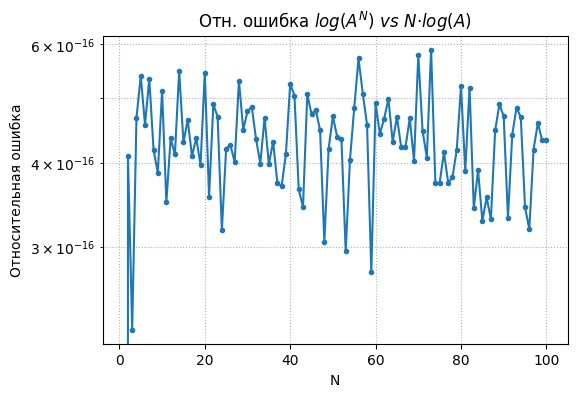

In [77]:
# Возьмём матрицу с реальными положительными и различными собственными значениями
A = A_lo
L = matrix_log_2x2(A)

Ns = np.arange(1, 101)
errs_pow = []
for N in Ns:
    A_pow = np.linalg.matrix_power(A, int(N))
    L_pow = matrix_log_2x2(A_pow)
    errs_pow.append(relative_error(L_pow, N * L, ord=2))

plt.figure(figsize=(6, 4))
plt.semilogy(Ns, errs_pow, marker='o', ms=3)
plt.xlabel('N')
plt.ylabel('Относительная ошибка')
plt.title(r'Отн. ошибка $log(A^N) \ vs \ N·log(A)$')
plt.grid(True, which='both', ls=':')
plt.show()


## Задача 2. Регуляризация и регрессия, метод наименьших квадратов и SVD (3 балла).

Есть три основных алгоритма вычисления сингулярного разложения, доступные в Python:

numpy.linalg.svd,

scipy.sparse. linalg.svds

sklearn.utils.extmath.randomized_svd.


Первый из них называется полным SVD, второй разреженным (берем только первые самые большие сингулярные числа, остальные обрезаем), третий рандомизированным SVD (приблизительное вычисление главного подмножества сингулярных значений и векторов). Создайте матрицу $A$ размера $n \times n(n=2000)$ со случайными элементами из стандартного нормального распределения и после этого:

- С помощью этих трёх алгоритмов (и теоремы Эккарта-Янга) аппроксимируйте матрицу $A$ матрицами ранга 2 . Вы получите матрицы $A_{\mathrm{svd}}, A_{\mathrm{svds}}$ и $A_{\mathrm{rsvd}}$. Измерьте времена выполнения.

- Вычислите нормы отклонений: $\left\|A-A_{\mathrm{svd}}\right\|_F \quad\left\|A-A_{\mathrm{svds}}\right\|_F \quad\left\|A-A_{\mathrm{rsvd}}\right\|_F$

- Вычислите ранги полученных матриц с помощью numpy.linalg.matrix_rank(A)

За каждый пункт по 1 баллу.

In [78]:
import scipy.sparse.linalg as spla
from sklearn.utils.extmath import randomized_svd

n = 2000
rng = np.random.default_rng(0)
A = rng.standard_normal((n, n))

# Полный
t0 = time.perf_counter()
U, s, Vt = np.linalg.svd(A, full_matrices=False)
A_svd = (U[:, :2] * s[:2]) @ Vt[:2, :]
t1 = time.perf_counter()
time_svd = t1 - t0

# Разреженный
t0 = time.perf_counter()
u, s2, vt = spla.svds(A, k=2, which='LM')
idx = np.argsort(s2)[::-1]
s2 = s2[idx]
u = u[:, idx]
vt = vt[idx, :]
A_svds = (u * s2) @ vt
t1 = time.perf_counter()
time_svds = t1 - t0

# Рандомизированный
t0 = time.perf_counter()
Ur, sr, Vtr = randomized_svd(A, n_components=2, random_state=0)
A_rsvd = (Ur * sr) @ Vtr
t1 = time.perf_counter()
time_rsvd = t1 - t0


err_svd = norm(A - A_svd, 'fro')
err_svds = norm(A - A_svds, 'fro')
err_rsvd = norm(A - A_rsvd, 'fro')

rank_svd = np.linalg.matrix_rank(A_svd)
rank_svds = np.linalg.matrix_rank(A_svds)
rank_rsvd = np.linalg.matrix_rank(A_rsvd)

print('Время (с): полный SVD =', time_svd, '| svds =', time_svds, '| randomized =', time_rsvd)
print('||A - A_⋅||_F:', err_svd, err_svds, err_rsvd)
print('Ранги:', rank_svd, rank_svds, rank_rsvd)


Время (с): полный SVD = 4.740117016015574 | svds = 0.7722500159870833 | randomized = 0.23420876602176577
||A - A_⋅||_F: 1995.7710688590935 1995.7710688590935 1995.9646039627285
Ранги: 2 2 2


## Задача 3. Решение нелинейных уравнений и поиск минимума функций. (4 балла).

Реализуйте метод простой итерации для нахождения решения следующих уравнений относительно $x$ :

(i) $1+\cos x=0$

(ii) $x^2=2$.

Используйте следующие итерационные формулы:

(i) $x_{k+1}=x_k+\frac{\cos z_k+1}{\sin z_k}$

(ii) $x_{k+1}=\frac{1}{2}\left(x_k+\frac{2}{x_k}\right)$.

В обоих случаях, стартуйте с $x_0=1$. Какова сходимость итераций (линейная/квадратичная) для случаев (i) и (ii)?

По 1 баллу за реализацию метода для каждого уравнения.

По 1 баллу за правильный ответ на вопрос (его можно получить как теоретически, так и с помощью графиков - оба варианта засчитываются).

In [79]:
import math

def fixed_point(phi, x0=1.0, tol=1e-12, maxiter=1000):
    xs = [float(x0)]
    for _ in range(maxiter):
        x_next = float(phi(xs[-1]))
        xs.append(x_next)
        if abs(xs[-1] - xs[-2]) <= tol * max(1.0, abs(xs[-2])):
            break
    return np.array(xs)

phi1 = lambda z: z + (math.cos(z) + 1.0) / math.sin(z)
xs1 = fixed_point(phi1, x0=1.0)

phi2 = lambda x: 0.5 * (x + 2.0 / x)
xs2 = fixed_point(phi2, x0=1.0)

x1_star = xs1[-1]
x2_star = xs2[-1]

true1 = math.pi
true2 = math.sqrt(2.0)

print(f"(i) Решение ≈ {x1_star:.12f}, |x-π| ≈ {abs(x1_star-true1):.3e}")
print(f"(ii) Решение ≈ {x2_star:.12f}, |x-√2| ≈ {abs(x2_star-true2):.3e}")


(i) Решение ≈ 3.141592646363, |x-π| ≈ 7.227e-09
(ii) Решение ≈ 1.414213562373, |x-√2| ≈ 2.220e-16


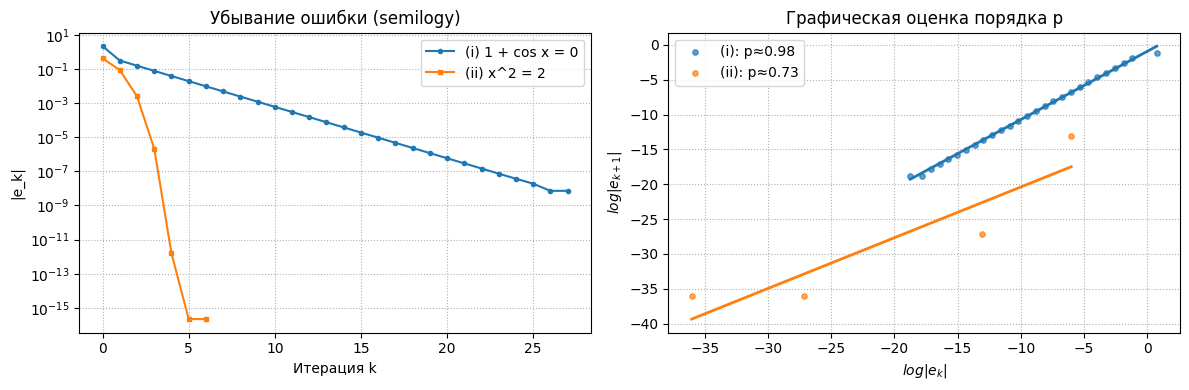

In [ ]:
errs1 = np.abs(xs1 - true1)
errs2 = np.abs(xs2 - true2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(range(len(errs1)), errs1, marker='o', ms=3, label='(i) 1 + cos x = 0')
axes[0].semilogy(range(len(errs2)), errs2, marker='s', ms=3, label='(ii) x^2 = 2')
axes[0].set_xlabel('Итерация k')
axes[0].set_ylabel('|e_k|')
axes[0].set_title('Убывание ошибки (semilogy)')
axes[0].grid(True, which='both', ls=':')
axes[0].legend()

ax = axes[1]

errs1_pos = errs1[errs1 > 0]
lx1 = np.log(errs1_pos[:-1])
ly1 = np.log(errs1_pos[1:])
coeffs1 = np.polyfit(lx1, ly1, 1)
p1, b1 = coeffs1[0], coeffs1[1]
order_idx1 = np.argsort(lx1)
ax.scatter(lx1, ly1, s=15, alpha=0.7, label=f'(i): p≈{p1:.2f}')
ax.plot(lx1[order_idx1], (p1 * lx1 + b1)[order_idx1], lw=2)

errs2_pos = errs2[errs2 > 0]
lx2 = np.log(errs2_pos[:-1])
ly2 = np.log(errs2_pos[1:])
coeffs2 = np.polyfit(lx2, ly2, 1)
p2, b2 = coeffs2[0], coeffs2[1]
order_idx2 = np.argsort(lx2)
ax.scatter(lx2, ly2, s=15, alpha=0.7, label=f'(ii): p≈{p2:.2f}')
ax.plot(lx2[order_idx2], (p2 * lx2 + b2)[order_idx2], lw=2)

ax.set_xlabel('$log |e_k|$')
ax.set_ylabel('$log |e_{k+1}|$')
ax.set_title('Графическая оценка порядка p')
ax.grid(True, ls=':')
ax.legend()
plt.tight_layout()
plt.show()


Из левого графика логично предположить, что сходимость i линейная, а ii квадратичная. Правый график подтверждает данные предположения. (для ii надо выкинуть превые 2 точки)